In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os
import joblib


In [2]:
df = pd.read_csv("/kaggle/input/bangladesh-flight/Flight_Price_Dataset_of_Bangladesh.csv")

In [3]:
df.head(5)

,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30 03:21:00,2025-05-30 04:02:09,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.607340,200.000000,4635.607340,Regular,56
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25 09:14:00,2025-04-25 23:17:20,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.806146,14886.570922,74130.377068,Regular,90


In [4]:
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column} Outliers: {len(outliers)} rows")
    return outliers

In [5]:
df.columns

Index(['Airline', 'Source', 'Source Name', 'Destination', 'Destination Name',
       'Departure Date & Time', 'Arrival Date & Time', 'Duration (hrs)',
       'Stopovers', 'Aircraft Type', 'Class', 'Booking Source',
       'Base Fare (BDT)', 'Tax & Surcharge (BDT)', 'Total Fare (BDT)',
       'Seasonality', 'Days Before Departure'],
      dtype='object')

In [6]:
col =['Airline', 'Source', 'Source Name', 'Destination', 'Destination Name',
       'Departure Date & Time', 'Arrival Date & Time', 'Duration (hrs)',
       'Stopovers', 'Aircraft Type', 'Class', 'Booking Source',
       'Base Fare (BDT)', 'Tax & Surcharge (BDT)', 'Total Fare (BDT)',
       'Seasonality', 'Days Before Departure']

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os



def preprocess_flight_data(df, target="Total Fare",test_size=0.2,random_state=42):
    """
    Clean and preprocess flight dataset safely (no data leakage).

    Returns:
        X_train, X_test, y_train, y_test
    """



    #Rename columns first (avoid confusion)
    df.rename(columns={
        'Total Fare (BDT)': 'Total Fare',
        'Base Fare (BDT)': 'Base Fare',
        'Tax & Surcharge (BDT)': 'Tax & Surcharge',
        'Seasonality': 'Season'
    }, inplace=True)

    #Convert numeric columns safely
    numeric_cols = [
        'Duration (hrs)',
        'Base Fare',
        'Tax & Surcharge',
        'Total Fare',
        'Days Before Departure'
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    #Remove negative fares
    fare_cols = ['Base Fare', 'Tax & Surcharge', 'Total Fare']
    for col in fare_cols:
        if col in df.columns:
            df = df[df[col] >= 0]

    # Handle missing values
    for col in numeric_cols:
        if col in df.columns:
            df[col].fillna(df[col].median(), inplace=True)

    categorical_cols = [
        'Airline', 'Source', 'Destination',
        'Stopovers', 'Aircraft Type',
        'Class', 'Booking Source', 'Season'
    ]

    for col in categorical_cols:
        if col in df.columns:
            df[col].fillna("Unknown", inplace=True)

    # Date Feature Engineering
    date_cols = ['Departure Date & Time', 'Arrival Date & Time']

    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    if 'Departure Date & Time' in df.columns:
        df['Departure Month'] = df['Departure Date & Time'].dt.month
        df['Departure Day'] = df['Departure Date & Time'].dt.day
        df['Departure Weekday'] = df['Departure Date & Time'].dt.weekday

    if 'Arrival Date & Time' in df.columns:
        df['Arrival Month'] = df['Arrival Date & Time'].dt.month
        df['Arrival Day'] = df['Arrival Date & Time'].dt.day
        df['Arrival Weekday'] = df['Arrival Date & Time'].dt.weekday

    df.drop(columns=date_cols, inplace=True, errors='ignore')

    #Encode categorical variables

    # Ordinal encoding
    df["Stopovers"] = df["Stopovers"].replace({
        "Direct": 0,
        "1 Stop": 1,
        "2 Stops": 2
    })

    df["Class"] = df["Class"].replace({
        "Economy": 0,
        "Business": 1,
        "First Class": 2
    })

    df["Booking Source"] = df["Booking Source"].replace({
        "Online Website": 0,
        "Travel Agency": 1,
        "Direct Booking": 2
    })

    # One-hot encoding
    nominal_cols = ['Airline', 'Source', 'Destination', 'Aircraft Type', 'Season']
    df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)


    for col in df.select_dtypes(include=['object']).columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.fillna(0)

    #Separate target BEFORE scaling
    X = df.drop(columns=[target])
    y = df[target]

    # Remove Base Fare & Tax if predicting Total Fare
    if target == "Total Fare":
        X = X.drop(columns=["Base Fare", "Tax & Surcharge"], errors="ignore")


    #Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state
    )

    # STEP 9: Scale ONLY feature columns (not target)
    numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns

    scaler = StandardScaler()

    X_train.loc[:, numeric_features] = scaler.fit_transform(X_train[numeric_features])
    X_test.loc[:, numeric_features] = scaler.transform(X_test[numeric_features])


    #Save cleaned dataset (optional)


    return X_train, X_test, y_train, y_test,scaler


In [8]:
X_train,X_test,y_train,y_test,scaler=preprocess_flight_data(df)

/tmp/ipykernel_55/1258492175.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_55/1258492175.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Assume you already have:
# X_train, X_test, y_train, y_test
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Train Linear Regression on log-transformed target
model = LinearRegression()
model.fit(X_train, y_train_log)

# Predict and invert transformation
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)  # convert back to original scale

# Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")



R²: 0.6546
MAE: 28515.94
RMSE: 47985.02


In [10]:
# Detect outliers using IQR
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = y_train[(y_train < lower) | (y_train > upper)]
print(f"{len(outliers)} outliers detected ({len(outliers)/len(y_train)*100:.2f}% of training data)")

# Optional: drop outliers
X_train_clean = X_train[~y_train.isin(outliers)]
y_train_clean = y_train[~y_train.isin(outliers)]


2724 outliers detected (5.97% of training data)


In [11]:
# After cleaning outliers
model_clean = LinearRegression()
model_clean.fit(X_train_clean, np.log1p(y_train_clean))
y_pred_clean = np.expm1(model_clean.predict(X_test))

# Compare
print(f"Original R²: {r2:.4f}")
print(f"Cleaned R²: {r2_score(y_test, y_pred_clean):.4f}")

Original R²: 0.6546
Cleaned R²: 0.6024


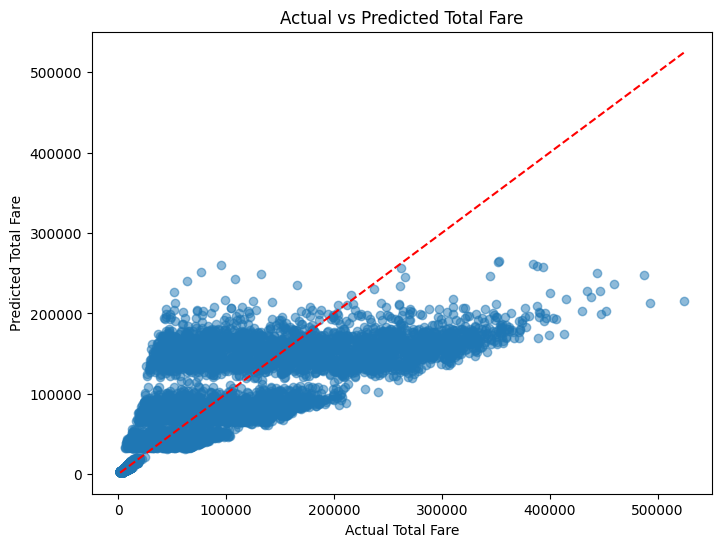

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Total Fare")
plt.ylabel("Predicted Total Fare")
plt.title("Actual vs Predicted Total Fare")
plt.show()


In [13]:
# Actual vs Predicted
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Residual": y_test - y_pred
})

# Top 10 rows
print(comparison.head(10))


             Actual      Predicted      Residual
30395   3443.680587    3755.411462   -311.730876
23048  69614.831211   36218.222770  33396.608441
46579   2598.866084    3652.329062  -1053.462979
47826  46213.937843  129366.437032 -83152.499189
52500  56482.820213   35815.717982  20667.102230
22882  11409.507002   33494.354232 -22084.847230
56239  73870.970083   76147.718089  -2276.748006
56024  93285.318817   79426.491180  13858.827637
17095   2184.296914    3174.665907   -990.368992
23585   7944.869135    6566.701828   1378.167307


# Advanced Modelling and Optimization 

Linear RegressionR²: 0.6546Adj R²: 0.6525MAE: 28515.94RMSE: 47985.02MAPE: 0.4142Explained Variance: 0.6661
RidgeR²: 0.6545Adj R²: 0.6524MAE: 28518.07RMSE: 47990.60MAPE: 0.4142Explained Variance: 0.6661
LassoR²: -0.2260Adj R²: -0.2335MAE: 58442.86RMSE: 90403.95MAPE: 2.1253Explained Variance: 0.0000
Decision TreeR²: 0.3466Adj R²: 0.3426MAE: 37547.64RMSE: 65996.91MAPE: 0.5659Explained Variance: 0.3466
Random ForestR²: 0.6357Adj R²: 0.6335MAE: 28986.05RMSE: 49281.96MAPE: 0.4147Explained Variance: 0.6476
Gradient BoostingR²: 0.6563Adj R²: 0.6542MAE: 28464.97RMSE: 47865.10MAPE: 0.4106Explained Variance: 0.6675

MODEL COMPARISON
            Model        R2  Adjusted R2          MAE          MSE         RMSE     MAPE  Explained Variance
Linear Regression  0.654599     0.652495 28515.935584 2.302562e+09 47985.019102 0.414184            0.666147
            Ridge  0.654518     0.652414 28518.069464 2.303098e+09 47990.603040 0.414153            0.666101
            Lasso -0.225992    -0.233458 58

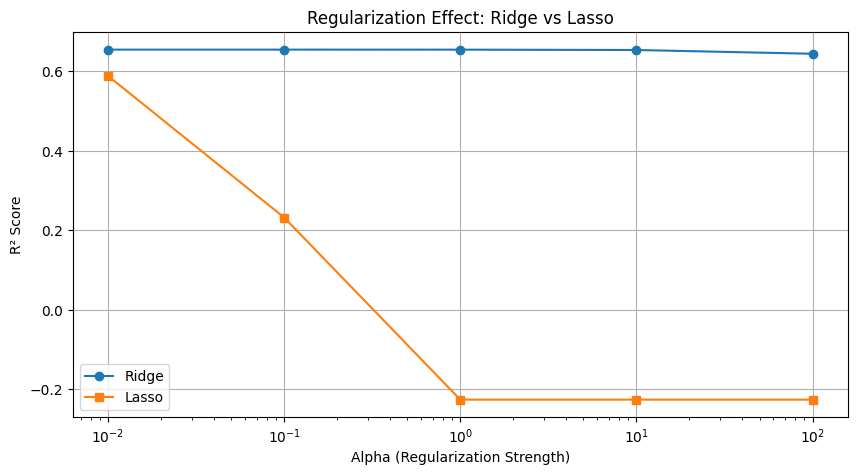

Ridge encourages small coefficients, Lasso can zero out features (feature selection).


In [14]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error,explained_variance_score
import pandas as pd
import numpy as np

# Use log-transformed target for all models
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# ========== 1. TRAIN MULTIPLE MODELS ==========

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}


def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Store results
results = []


for name, model in models.items():
    model.fit(X_train, y_train_log)
    y_pred = np.expm1(model.predict(X_test))

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    evs = explained_variance_score(y_test, y_pred)
    adj_r2 = adjusted_r2(r2, X_test.shape[0], X_test.shape[1])

    results.append({
        "Model": name,
        "R2": r2,
        "Adjusted R2": adj_r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "Explained Variance": evs
    })

    print(f"""{name}R²: {r2:.4f}Adj R²: {adj_r2:.4f}MAE: {mae:.2f}RMSE: {rmse:.2f}MAPE: {mape:.4f}Explained Variance: {evs:.4f}""")

# ========== 2. MODEL COMPARISON TABLE ==========

results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(results_df.to_string(index=False))
print("\nBest Model (by R²):", results_df.loc[results_df['R2'].idxmax(), 'Model'])

# ========== 3. HYPERPARAMETER TUNING (Top 3 Models) ==========

print("\n" + "="*50)
print("HYPERPARAMETER TUNING")
print("="*50)

# Ridge
ridge_params = {'alpha': [0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train, y_train_log)
print(f"\nRidge - Best alpha: {ridge_grid.best_params_['alpha']}, CV R²: {ridge_grid.best_score_:.4f}")

# Random Forest
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), 
                       rf_params, cv=3, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train_log)
print(f"Random Forest - Best params: {rf_grid.best_params_}, CV R²: {rf_grid.best_score_:.4f}")

# Gradient Boosting
gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), 
                       gb_params, cv=3, scoring='r2', n_jobs=-1)
gb_grid.fit(X_train, y_train_log)
print(f"Gradient Boosting - Best params: {gb_grid.best_params_}, CV R²: {gb_grid.best_score_:.4f}")

# ========== 4. EVALUATE BEST MODELS ==========

print("\n" + "="*50)
print("TUNED MODEL PERFORMANCE")
print("="*50)

best_models = {
    'Ridge (Tuned)': ridge_grid.best_estimator_,
    'Random Forest (Tuned)': rf_grid.best_estimator_,
    'Gradient Boosting (Tuned)': gb_grid.best_estimator_
}

tuned_results = []
for name, model in best_models.items():
    y_pred = np.expm1(model.predict(X_test))
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    tuned_results.append({'Model': name, 'R2': r2, 'MAE': mae, 'RMSE': rmse})
    print(f"{name}: R²={r2:.4f}, MAE={mae:.2f}, RMSE={rmse:.2f}")

# ========== 5. REGULARIZATION DEMO (Ridge vs Lasso) ==========

print("\n" + "="*50)
print("REGULARIZATION EFFECT")
print("="*50)

alphas = [0.01, 0.1, 1, 10, 100]
ridge_scores = []
lasso_scores = []

for alpha in alphas:
    # Ridge
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train_log)
    ridge_r2 = r2_score(y_test, np.expm1(ridge.predict(X_test)))
    ridge_scores.append(ridge_r2)
    
    # Lasso
    lasso = Lasso(alpha=alpha, max_iter=5000)
    lasso.fit(X_train, y_train_log)
    lasso_r2 = r2_score(y_test, np.expm1(lasso.predict(X_test)))
    lasso_scores.append(lasso_r2)

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(alphas, ridge_scores, marker='o', label='Ridge')
plt.plot(alphas, lasso_scores, marker='s', label='Lasso')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R² Score')
plt.title('Regularization Effect: Ridge vs Lasso')
plt.legend()
plt.grid(True)
plt.show()

print("Ridge encourages small coefficients, Lasso can zero out features (feature selection).")

In [15]:
train_pred = np.expm1(gb_grid.best_estimator_.predict(X_train))
test_pred = np.expm1(gb_grid.best_estimator_.predict(X_test))

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))


Train R2: 0.6628100137290153
Test R2: 0.6563227507441036


In [16]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_grid.best_estimator_.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(15))


                     Feature  Importance
2             Duration (hrs)    0.668919
4                      Class    0.166869
44           Destination_CCU    0.154680
6      Days Before Departure    0.005442
67            Season_Regular    0.003131
66               Season_Hajj    0.000332
68    Season_Winter Holidays    0.000089
10             Arrival Month    0.000073
55           Destination_KUL    0.000067
48           Destination_DEL    0.000058
63  Aircraft Type_Boeing 737    0.000043
37                Source_CXB    0.000026
7            Departure Month    0.000024
9          Departure Weekday    0.000021
51           Destination_IST    0.000020


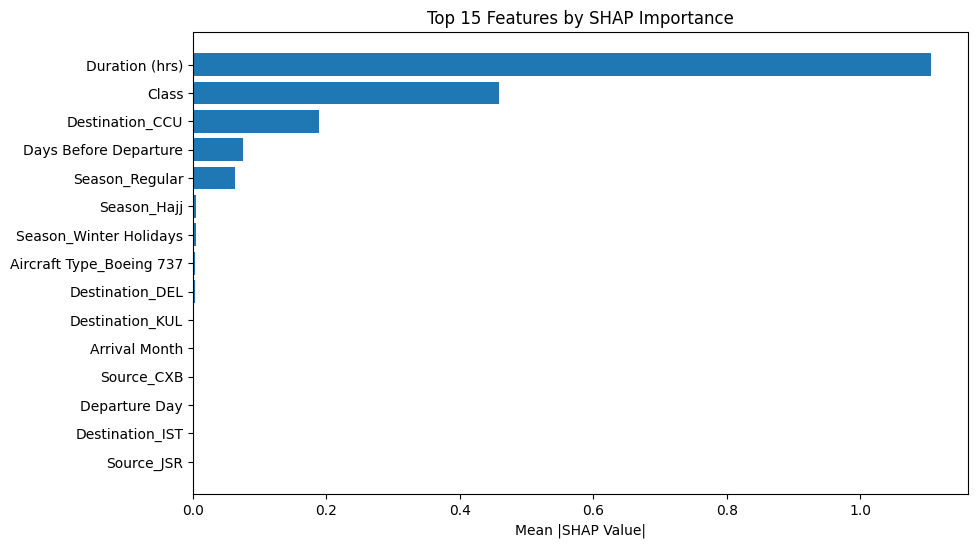

In [17]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Ensure numeric
X_train = X_train.astype(float)
X_test = X_test.astype(float)

model = gb_grid.best_estimator_

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Mean absolute SHAP values
shap_importance = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Importance": shap_importance
}).sort_values(by="SHAP Importance", ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(shap_df["Feature"][:15], shap_df["SHAP Importance"][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Features by SHAP Importance")
plt.xlabel("Mean |SHAP Value|")
plt.show()


In [18]:


# Save best model
joblib.dump(gb_grid.best_estimator_, "flight_price_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save feature column order
joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")


['feature_columns.pkl']